# Homework W13 - Classification
Nama  : Alya Rahma Rahadian
Batch : 61

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Telecom_Customers_Churn.csv')
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


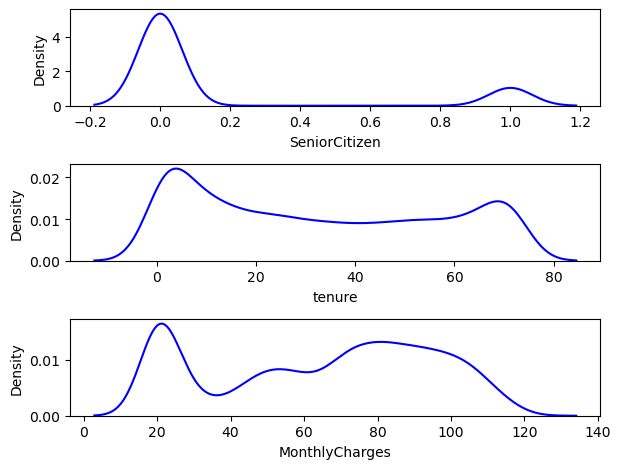

In [7]:
features = df.select_dtypes(["float64", "int64"]).columns
for i in range(0, len(features)): 
    plt.subplot (3, 1, i+1) 
    sns.kdeplot(x=df[features[i]], color='blue') 
    plt.xlabel(features[i])
    plt.tight_layout()

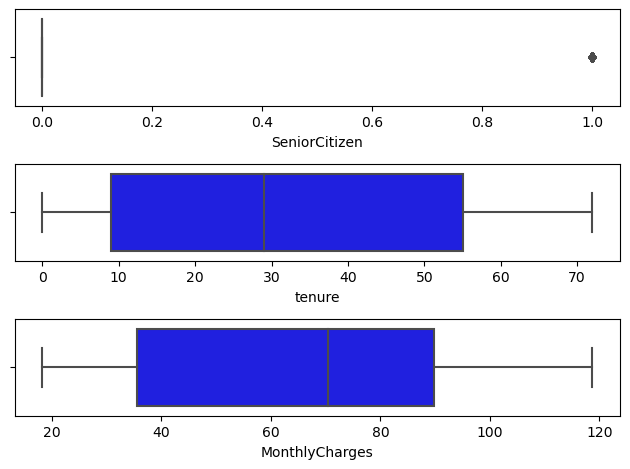

In [8]:
features = df.select_dtypes(["float64", "int64"]).columns
for i in range(0, len(features)): 
    plt.subplot (3, 1, i+1) 
    sns.boxplot(x=df[features[i]], color='blue') 
    plt.xlabel(features[i])
    plt.tight_layout()

In [9]:
sns.set(rc={'figure.figsize':(20.7,8.27)})
sns.set_style("whitegrid")
sns.color_palette("dark")
plt.style.use("fivethirtyeight")

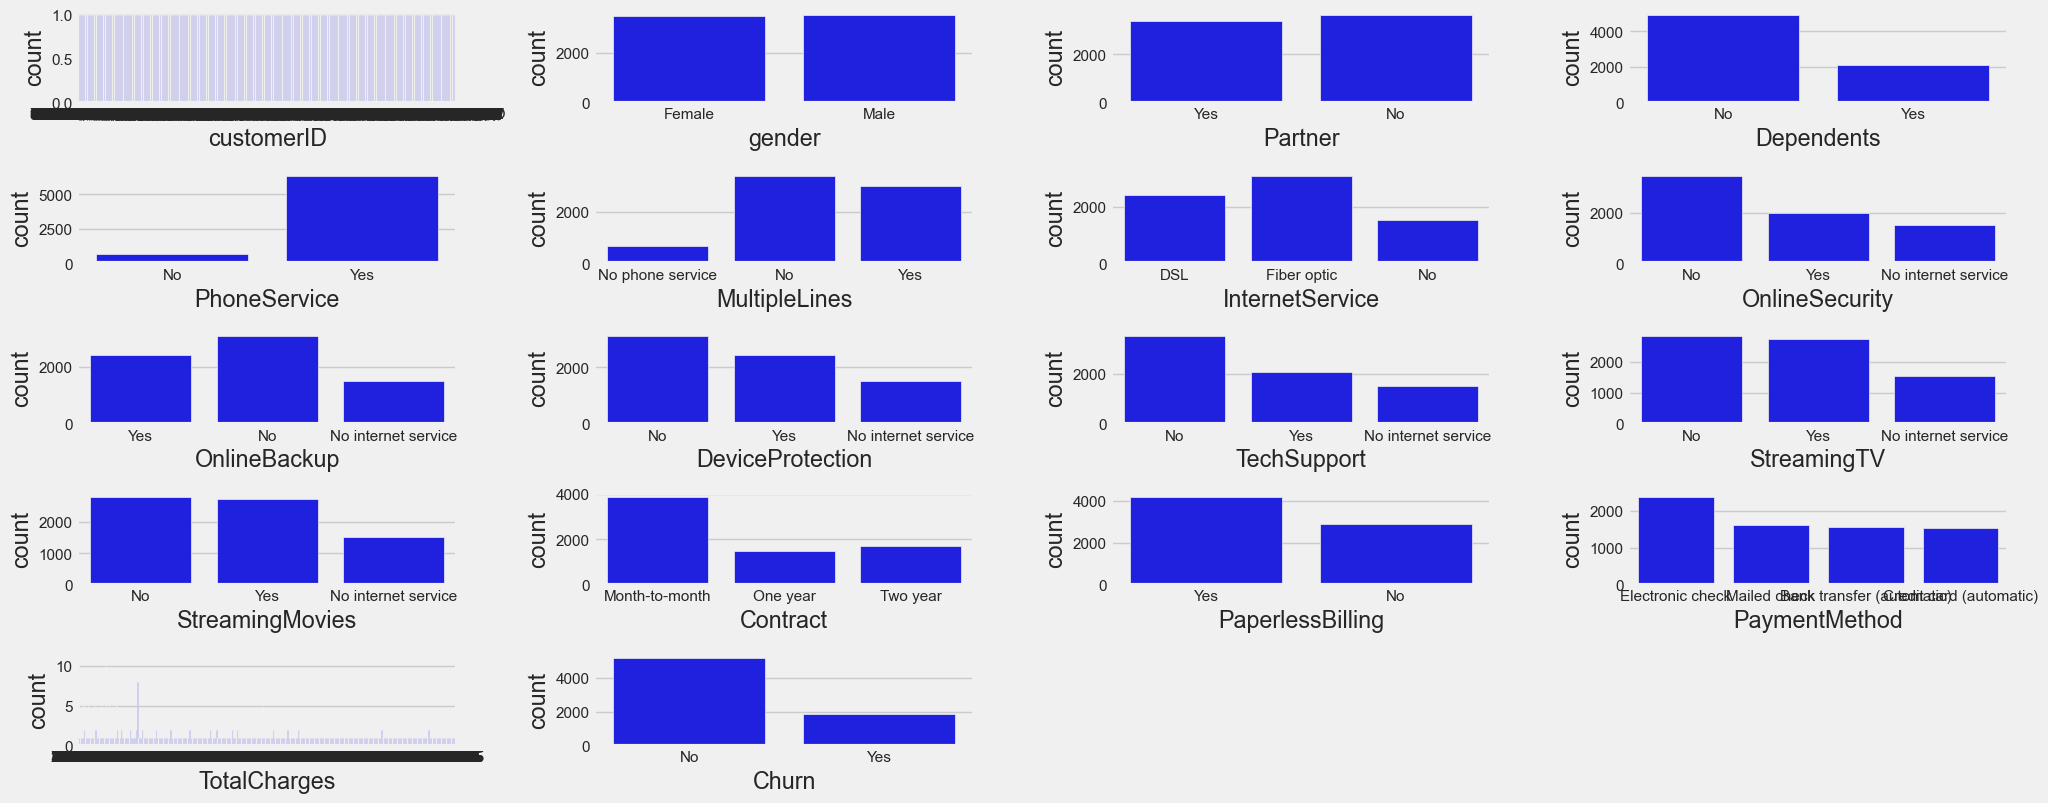

In [10]:
#loading lama karena cust id
features = df.select_dtypes(["object"]).columns

for i in range(0, len(features)): 
    plt.subplot (5, 4, i+1) 
    sns.countplot(x=df[features[i]], color='blue') 
    plt.xlabel(features[i])
    plt.tight_layout()

In [ ]:
# Ganti tipe data Senior Citizen jadi boolean
df['SeniorCitizen'] = df['SeniorCitizen'].astype("object")

# Ganti tipe data Total Charges menjadi float64
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

# Drop kolom id, karena tidak akan dipakai dalam model akhir dan tidak dapat memberikan insight, 
## juga untuk mempercepat proses visualisasi
df = df.drop(columns=['customerID'])

df.info()

In [ ]:
features = df.select_dtypes(["float64", "int64"]).columns
for i in range(0, len(features)): 
    plt.subplot (3, 1, i+1) 
    sns.boxplot(x=df[features[i]], color='blue') 
    plt.xlabel(features[i])
    plt.tight_layout()

In [ ]:
features = df.select_dtypes(["float64", "int64"]).columns
for i in range(0, len(features)): 
    plt.subplot (3, 1, i+1) 
    sns.kdeplot(x=df[features[i]], color='blue') 
    plt.xlabel(features[i])
    plt.tight_layout()

In [ ]:
features = df.select_dtypes(["object","boolean"]).columns
for i in range(0, len(features)): 
    plt.subplot (6, 3, i+1) 
    sns.countplot(x=df[features[i]], color='blue') 
    plt.xlabel(features[i])
    plt.tight_layout()

In [ ]:
df.describe(include='object')

In [ ]:
df.corr()

## Multivariate Analysis

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='Blues', annot=True, fmt='.2f')

# Data Cleaning

In [ ]:
df.shape

In [ ]:
df.duplicated().sum()

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

In [ ]:
df.isnull().values.any()

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().values.any()

In [ ]:
df.shape

In [ ]:
numericals = df.select_dtypes(include=['int64', 'float64'], exclude=['bool'])

In [ ]:
from scipy.stats import zscore
import numpy as np

z_scores = np.abs(zscore(numericals, nan_policy='omit'))

In [ ]:
outliers_before = pd.Series(
    (z_scores > 3).sum(axis=0),
    index=numericals.columns,
    name='outliers_before'
)

In [ ]:
(z_scores > 3).sum(axis=0)
outliers_before = (z_scores > 3).sum()
outliers_before

In [ ]:
df.shape

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='Blues', annot=True, fmt='.2f')

## Uji Chi Square & Cramer's V

In [ ]:
from scipy.stats import chi2_contingency, spearmanr

In [ ]:
categoricals = (
    df
    .select_dtypes(include=['bool', 'object'])
    .drop(columns=['customerID'], errors='ignore')
)

In [ ]:
categoricals.info()

In [ ]:
chi_results = []

for col1 in categoricals:
    for col2 in categoricals:
        if col1 != col2:
            table = pd.crosstab(df[col1], df[col2])
            chi2, p, _, _ = chi2_contingency(table)
            chi_results.append([col1, col2, p])

chi_df = pd.DataFrame(
    chi_results,
    columns=['var1', 'var2', 'p_value']
)

In [ ]:
chi_results

In [ ]:
alpha = 0.05

chi_df = chi_df.copy()

# buang customerID
chi_df = chi_df[(chi_df['var1'] != 'customerID') & (chi_df['var2'] != 'customerID')]

# buang pasangan duplikat (A,B) & (B,A)
chi_df['pair'] = chi_df.apply(lambda r: tuple(sorted([r['var1'], r['var2']])),axis=1)

chi_df = chi_df.drop_duplicates(subset='pair').drop(columns='pair')
chi_df

In [ ]:
chi_df['decision'] = np.where(chi_df['p_value'] < alpha,'Tolak H0','Gagal tolak H0')
chi_df['interpretation'] = np.where(chi_df['p_value'] < alpha,'Ada hubungan signifikan','Tidak ada hubungan signifikan')

In [ ]:
chi_table = chi_df[['var1', 'var2', 'p_value', 'decision', 'interpretation']].sort_values('p_value')

chi_table

In [ ]:
def cramers_v(table):
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

In [ ]:
cramer_results = []

cols = categoricals.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1, col2 = cols[i], cols[j]
        table = pd.crosstab(categoricals[col1], categoricals[col2])
        v = cramers_v(table)
        cramer_results.append([col1, col2, v])

In [ ]:
cramer_df = pd.DataFrame(cramer_results,columns=['var1', 'var2', 'cramers_v'])

In [ ]:
def interpret_v(v):
    if v < 0.1:
        return 'Sangat lemah'
    elif v < 0.3:
        return 'Lemah–sedang'
    elif v < 0.5:
        return 'Sedang–kuat'
    else:
        return 'Kuat'

cramer_df['strength'] = cramer_df['cramers_v'].apply(interpret_v)


In [ ]:
cramer_table = cramer_df.sort_values(
    'cramers_v', ascending=False
)

cramer_table

In [ ]:
cramer_kuat = cramer_df[cramer_df['cramers_v'] >= 0.5] \
    .sort_values('cramers_v', ascending=False)

cramer_kuat

In [ ]:
churn_cramer = cramer_table[
    (cramer_table['var1'] == 'Churn') |
    (cramer_table['var2'] == 'Churn')
].copy()

In [ ]:
col_a, col_b = cramer_table.columns[:2]

churn_cramer = cramer_table[
    (cramer_table[col_a] == 'Churn') |
    (cramer_table[col_b] == 'Churn')
].copy()

churn_cramer['feature'] = np.where(
    churn_cramer[col_a] == 'Churn',
    churn_cramer[col_b],
    churn_cramer[col_a]
)

churn_cramer = churn_cramer[['feature', 'cramers_v', 'strength']] \
    .sort_values('cramers_v', ascending=False)
churn_cramer

## Uji T

In [ ]:
from scipy.stats import ttest_ind

group1 = df[df["Churn"] == "No"]["tenure"]
group2 = df[df["Churn"] == "Yes"]["tenure"]

t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
t_stat, p_value

In [ ]:
group1 = df[df["Churn"] == "No"]["MonthlyCharges"]
group2 = df[df["Churn"] == "Yes"]["MonthlyCharges"]

t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
t_stat, p_value

In [ ]:
group1 = df[df["Churn"] == "No"]["TotalCharges"]
group2 = df[df["Churn"] == "Yes"]["TotalCharges"]

t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
t_stat, p_value

## Feature Engineering

In [ ]:
df_fe = df.copy()

# target
df_fe["Churn"] = df_fe["Churn"].map({"Yes": 1, "No": 0})

# binary categorical
binary_cols = [
    "gender", "Partner", "Dependents",
    "PhoneService", "PaperlessBilling" ]

binary_map = {
    "Yes": 1, "No": 0,
    "Male": 1, "Female": 0
}

for col in binary_cols:
    df_fe[col] = df_fe[col].map(binary_map)

In [ ]:
df_fe.head(5)

In [ ]:
multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]

df_fe = pd.get_dummies(
    df_fe,
    columns=multi_cat_cols,
    drop_first=True
)

In [ ]:
df_fe.head(5)

In [ ]:
df_fe.info()

In [ ]:
service_cols = ["PhoneService","MultipleLines_Yes", "OnlineSecurity_Yes", "OnlineBackup_Yes", "DeviceProtection_Yes",
    "TechSupport_Yes","StreamingTV_Yes", "StreamingMovies_Yes"]

df_fe["NumServices"] = df_fe[service_cols].sum(axis=1)
df_fe

In [ ]:
df_fe.describe()

## Klasifikasi

In [ ]:
from sklearn.model_selection import train_test_split

X = df_fe.drop(columns=["Churn"])
y = df_fe["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
from sklearn.metrics import recall_score, roc_auc_score

def eval_classification(y_true, y_pred, y_prob):
    print("Recall :", recall_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_prob))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="liblinear"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\nModel: {name}")
    eval_classification(y_test, y_pred, y_prob)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

rf_tuned = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=20,
    cv=5,
    scoring="recall",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

In [ ]:
best_rf = rf_tuned.best_estimator_

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Random Forest (Tuned)")
eval_classification(y_test, y_pred, y_prob)

In [ ]:
import matplotlib.pyplot as plt

importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
importances.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Fit ulang best model (Logistic Regression)
best_model = LogisticRegression(
    max_iter=1000,
    solver="liblinear"
)

best_model.fit(X_train, y_train)

# Predicted probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# ROC components
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Best Model (Logistic Regression)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
## Model dengan Phone Service dan others Dropped (Represented by NumService)

In [ ]:
from sklearn.model_selection import train_test_split

X = df_fe.drop(columns=["Churn","PhoneService", "MultipleLines_Yes", "OnlineSecurity_Yes", "OnlineBackup_Yes", "DeviceProtection_Yes",
    "TechSupport_Yes","StreamingTV_Yes", "StreamingMovies_Yes"])
y = df_fe["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
from sklearn.metrics import recall_score, roc_auc_score

def eval_classification(y_true, y_pred, y_prob):
    print("Recall :", recall_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_prob))

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="liblinear"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\nModel: {name}")
    eval_classification(y_test, y_pred, y_prob)

In [68]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

rf_tuned = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=20,
    cv=5,
    scoring="recall",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='recall')

In [69]:
best_rf = rf_tuned.best_estimator_

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Random Forest (Tuned)")
eval_classification(y_test, y_pred, y_prob)

Random Forest (Tuned)
Recall : 0.5067385444743935
ROC AUC: 0.835254025479672


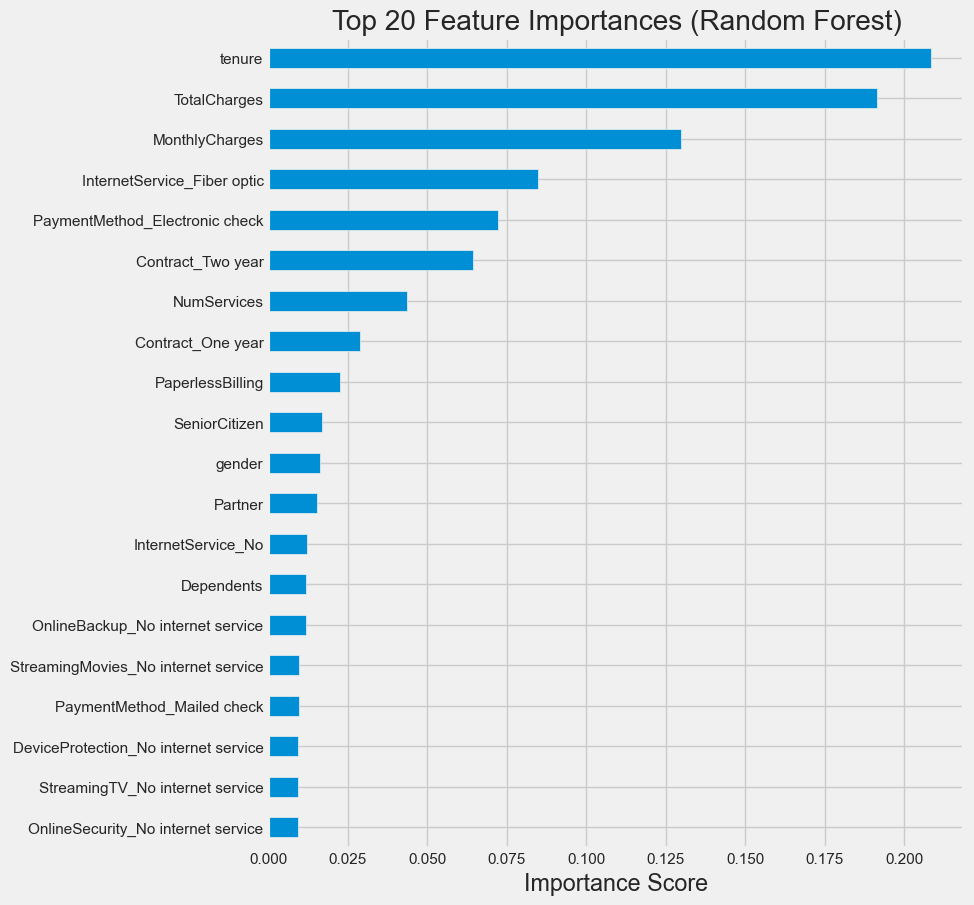

In [70]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
importances.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

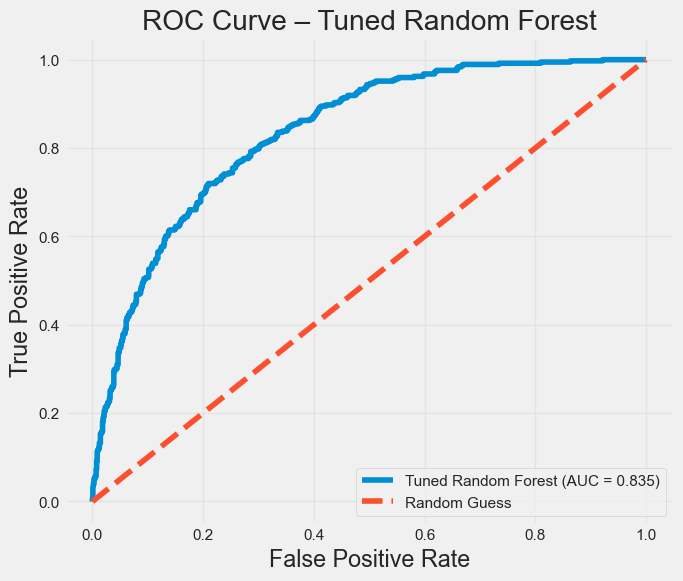

In [71]:
# Predicted probabilities dari tuned Random Forest
y_prob = best_rf.predict_proba(X_test)[:, 1]

# ROC components
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(7, 6))
plt.plot(
    fpr, 
    tpr, 
    label=f"Tuned Random Forest (AUC = {roc_auc:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Tuned Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

The best model for Random Forest is the one that excludes predictors with indications of multicollinearity, with some variables represented through feature engineering (e.g., numservices), and has been tuned so that Recall improves to 50.67% and ROC AUC reaches 83.52.
Meanwhile, for Logistic Regression, the best model uses all predictors, achieving a Recall of 53.9% and an AUC of 84.7%.